In [2]:
!jupyter nbconvert --to pdf

This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Execute the notebook prior to export.
    Equivalent to: [--ExecutePr

## What is Simple Linear Regression?
Simple Linear Regression is finding the best relationship between the input variable x (independent variable) and the expected variable y (dependent variable). The linear relationship between these two variables can be represented by a straight line called regression line.

Formula :- $y = b0 + b1x$

What do terms represent?
- $y$ is the response or the target variable
- $x$ is the feature
- $b1$ is the coefficient of x
- $b0$ is the intercept

#### Estimating ("Learning") Model Coefficients

The coefficients are estimated using the **least-squares criterion**,  i.e.,
the best fit line has to be calculated that minimizes the **sum of squared residuals** (or "sum of squared errors").

## Diving into the code

## Dividing the code into steps for better understanding:
1. Load the dataset.
2. Visualize the data.
3. Training Simple Linear Regression Model.

In [ ]:
cd /content/drive/MyDrive/ML/Regression

/content/drive/MyDrive/ML/Regression


## Step1 : Load Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/ML/Regression/dataset/Salary_Data.csv')

In [ ]:
dataset.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [ ]:
dataset.shape

(30, 2)

Here, 'YearsExperience' is the independent variable and 'Salary' is the dependent variable which will be predicted based on the value of 'YearsExperience'.

In [ ]:
X = dataset.drop(['Salary'],axis=True)
y = dataset['Salary']

In [ ]:
#Now Split The Data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((24, 1), (6, 1), (24,), (6,))

## Step 2: Visualize the data.

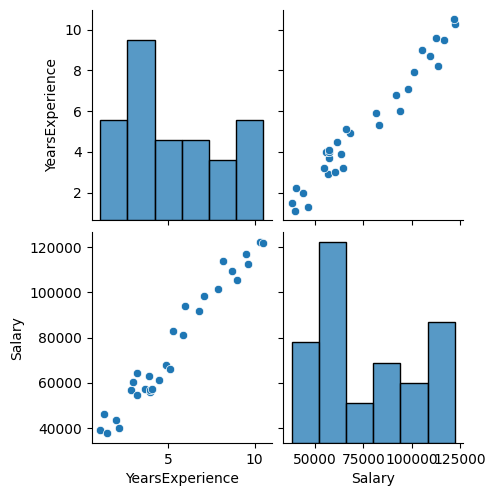

In [ ]:
# Visualize Whole Data set
sns.pairplot(dataset)

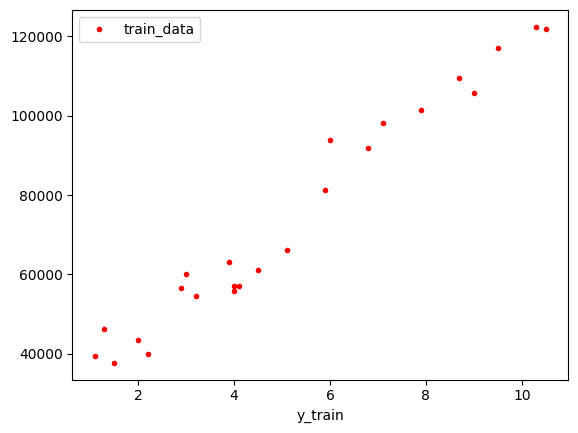

In [ ]:
# Visualize Only Train data
plt.plot(X_train,y_train,'r.',label='train_data')
plt.xlabel('X_train')
plt.xlabel('y_train')
plt.legend()
plt.show()

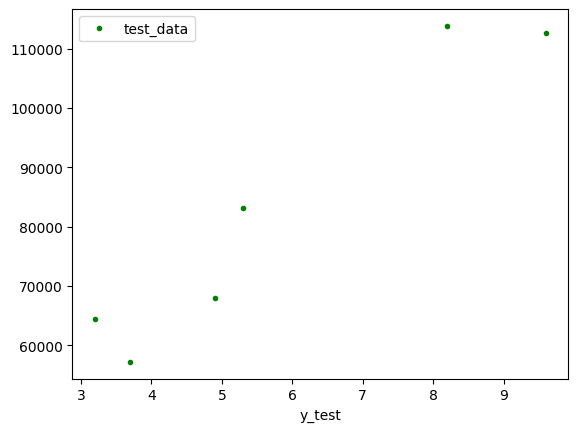

In [ ]:
# Visualize Only Test data
plt.plot(X_test,y_test,'g.',label='test_data')
plt.xlabel('X_test')
plt.xlabel('y_test')
plt.legend()
plt.show()

In The Above three graph clealr shows that the data is linearly deparable so here we use Linear Regression

#### Ok, now we hope the dataset is pretty clear by now. We will move to the next step now!

## Step 3 :Training Simple Linear Regression Model.

In [ ]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

### Predicting the Test set results

In [ ]:
y_pred = regressor.predict(X_test).round(1)

In [ ]:
calculation = pd.DataFrame(np.c_[y_test,y_pred], columns = ["Original Salary","Predict Salary"])
calculation

,Original Salary,Predict Salary
0,112635.0,115790.2
1,67938.0,71498.3
2,113812.0,102596.9
3,83088.0,75267.8
4,64445.0,55477.8
5,57189.0,60189.7


In [ ]:
print("Training Accuracy :", regressor.score(X_train, y_train))
print("Testing Accuracy :", regressor.score(X_test, y_test))

Training Accuracy : 0.9645401573418146
Testing Accuracy : 0.9024461774180497


## Visualising the Training set results

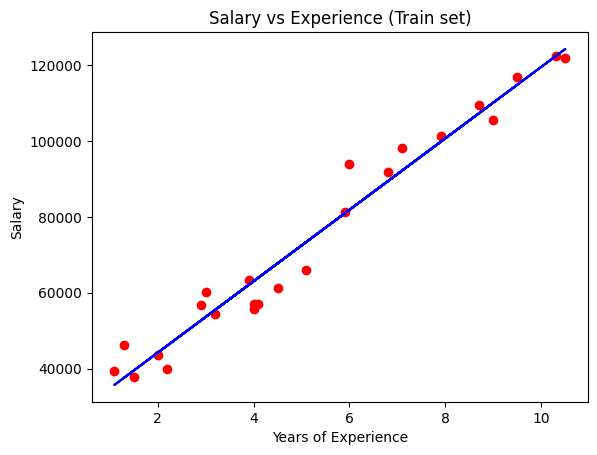

In [ ]:
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Train set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

## Visualising the Training set results

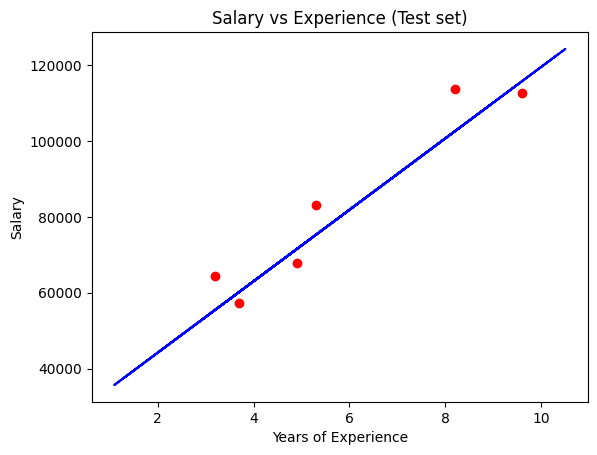

In [ ]:
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

### This is All About Simple Linear Regresion .

In [ ]:
import pickle

In [ ]:
# Save Model To a File Using Python Pickle
with open('Linear_Regression_Model','wb') as file:
    pickle.dump(regressor,file)

In [ ]:
# Load Saved Model
with open('Linear_Regression_Model','rb') as file:
    my_pickle_model = pickle.load(file)

In [ ]:
my_pickle_model.predict([[1.1]])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([35687.77986711])

In [ ]:
import joblib


In [ ]:
# Save Trained Model Using joblib

joblib.dump(regressor, 'joblib_model_LinearRegression')

['joblib_model_LinearRegression']

In [ ]:
# Save Trained Model Using joblib

joblib.dump(regressor, 'joblib_model_LinearRegression')

['joblib_model_LinearRegression']

In [ ]:
# Loading the Model
my_joblib_model = joblib.load('joblib_model_LinearRegression')

In [ ]:
# Using the Model
my_joblib_model.predict([[1.1]])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([35687.77986711])

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming you have predictions and true values
y_pred = regressor.predict(X_test)

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# R-squared (R²) Score
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 49830096.86
Mean Absolute Error (MAE): 6286.45
R-squared (R²): 0.90


In [ ]:
# Compute R²
r2 = r2_score(y_test, y_pred)

# Number of samples (n) and predictors (k)
n = X_test.shape[0]  # Number of samples
k = X_test.shape[1]  # Number of features

# Compute Adjusted R²
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print(f"R-squared (R²): {r2:.2f}")
print(f"Adjusted R-squared: {adjusted_r2:.2f}")

R-squared (R²): 0.90
Adjusted R-squared: 0.88


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
